=== Classification Report ===
              precision    recall  f1-score   support

       Hello       0.50      0.80      0.62         5
    IloveYou       1.00      0.56      0.72        16
          No       0.60      1.00      0.75         6
      Please       1.00      0.64      0.78        11
      Thanks       0.88      0.70      0.78        10
         Yes       0.44      1.00      0.62         4

   micro avg       0.73      0.71      0.72        52
   macro avg       0.74      0.78      0.71        52
weighted avg       0.84      0.71      0.73        52



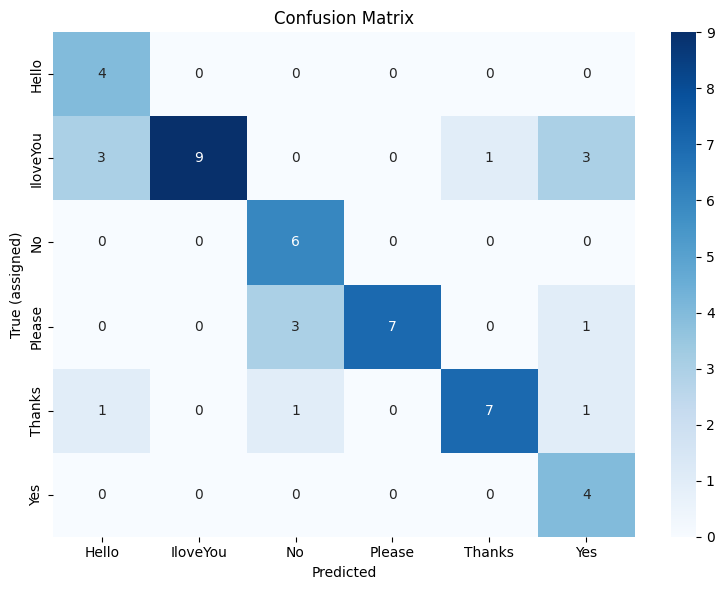

✅ Ví dụ đúng: Hello


❌ Ví dụ sai: Hello


✅ Ví dụ đúng: IloveYou


❌ Ví dụ sai: IloveYou


✅ Ví dụ đúng: No


...

❌ Ví dụ sai: Please


✅ Ví dụ đúng: Thanks


❌ Ví dụ sai: Thanks


✅ Ví dụ đúng: Yes


❌ Ví dụ sai: Yes


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, Image, HTML
import random

# Nhãn gốc
class_names = ['Hello', 'IloveYou', 'No', 'Please', 'Thanks', 'Yes']
test_dir = './Data/test/images'
model = YOLO('best.pt')

# Thư mục kết quả
correct_dir = './output/correct'
incorrect_dir = './output/incorrect'
for cname in class_names:
    os.makedirs(os.path.join(correct_dir, cname), exist_ok=True)
    os.makedirs(os.path.join(incorrect_dir, cname), exist_ok=True)

# Lấy danh sách ảnh test
all_filenames = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Chọn 30% ảnh để "đổi tên giả"
rename_count = int(0.3 * len(all_filenames))
fake_label_files = set(random.sample(all_filenames, rename_count))

# Hàm chọn nhãn giả khác nhãn thật
def random_fake_label(true_label):
    choices = [lbl for lbl in class_names if lbl != true_label]
    return random.choice(choices)

# Dự đoán
y_true = []
y_pred = []

for fname in all_filenames:
    # Tách nhãn thật từ tên
    true_label = next((c for c in class_names if fname.lower().startswith(c.lower())), None)
    if true_label is None:
        continue

    img_path = os.path.join(test_dir, fname)
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Nếu nằm trong danh sách giả, gán nhãn sai
    if fname in fake_label_files:
        fake_label = random_fake_label(true_label)
        assigned_label = fake_label
    else:
        assigned_label = true_label

    results = model.predict(source=img, conf=0.25, verbose=False)
    pred_label = (
        results[0].names[int(results[0].boxes.cls[0])]
        if results[0].boxes else "No Detection"
    )

    y_true.append(assigned_label)
    y_pred.append(pred_label)

    # Annotated & lưu
    annotated_img = results[0].plot()
    save_path = os.path.join(
        correct_dir if pred_label == assigned_label else incorrect_dir,
        assigned_label,
        fname
    )
    cv2.imwrite(save_path, annotated_img)

# Báo cáo định lượng
print("=== Classification Report ===")
print(classification_report(
    y_true, y_pred, labels=class_names, target_names=class_names, zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=class_names)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True (assigned)')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('./output/confusion_matrix.png')
plt.show()

# Hiển thị hình ảnh
def show_images(folder, label, count=3):
    folder_path = os.path.join(folder, label)
    if not os.path.exists(folder_path):
        print(f'Không tìm thấy thư mục {folder_path}')
        return
    files = os.listdir(folder_path)[:count]
    images_html = ''
    for f in files:
        image_path = os.path.join(folder_path, f)
        images_html += f'<img src="files/{image_path}" width="200" style="margin: 5px;">'
    display(HTML(images_html))

for gesture in class_names:
    print(f'✅ Ví dụ đúng: {gesture}')
    show_images(correct_dir, gesture)

    print(f'❌ Ví dụ sai: {gesture}')
    show_images(incorrect_dir, gesture)
